# 단계 4 — 소셜 네트워크 분석

**목적**: 팔로우·방문 그래프의 구조를 비교하고, 중심성·커뮤니티·링크 예측으로 소셜 구조가 활성화에 미치는 영향을 분석한다.  
**사용 데이터**: `04a_follow_edges`, `04b_visit_edges`, `04c_nodes`


In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from networkx.algorithms.community import louvain_communities
import warnings
warnings.filterwarnings('ignore')


BASE = "../data"
follow = pd.read_csv(f"{BASE}/04a_follow_edges_20260524.csv")
visit  = pd.read_csv(f"{BASE}/04b_visit_edges_20260524.csv")
nodes  = pd.read_csv(f"{BASE}/04c_nodes_20260524.csv")
node_status = nodes.set_index('user_id')['activity_status'].to_dict()

G_follow   = nx.from_pandas_edgelist(follow, 'source', 'target', create_using=nx.DiGraph())
G_visit    = nx.from_pandas_edgelist(visit,  'source', 'target', create_using=nx.DiGraph())
G_follow_u = G_follow.to_undirected()
G_visit_u  = G_visit.to_undirected()

print(f"팔로우 그래프: {G_follow.number_of_nodes()}노드, {G_follow.number_of_edges()}엣지")
print(f"방문 그래프:   {G_visit.number_of_nodes()}노드, {G_visit.number_of_edges()}엣지")

import matplotlib.font_manager as fm
fm.fontManager.addfont('/Users/hongseogju/anaconda3/lib/python3.11/site-packages/koreanize_matplotlib/fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

/Users/hongseogju/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


팔로우 그래프: 164노드, 207엣지
방문 그래프:   998노드, 5043엣지


## 모델 선택 근거

- **커뮤니티 탐지 — Louvain 선택**
  - 대안: Girvan-Newman (엣지 제거 방식, 대규모 그래프에서 O(m²n)으로 느림), Label Propagation (결정론적이지 않아 재현성 낮음)
  - Louvain: 모듈러리티 최적화 기반, O(n log n)으로 빠름, seed 고정으로 재현 가능. 방문 그래프 998노드에 최적.

- **Link Prediction — Adamic-Adar 선택**
  - 대안: Common Neighbors (단순 교집합, 이웃 수에 따른 가중치 없음), Jaccard (전체 이웃 수 정규화, 희소 그래프에서 불안정)
  - Adamic-Adar: 공통 이웃의 연결도에 역로그 가중치 → 많은 사람이 알고 있는 허브보다 소규모 공통 친구를 더 높이 평가. 팔로우 그래프처럼 희소한 그래프에 적합.

- **중심성 — PageRank + In/Out-degree**
  - PageRank: 방향성과 가중치를 반영한 전역 중요도. 단순 degree count의 한계 보완.


        노드      엣지        밀도  최대WCC  WCC수   클러스터링계수
팔로우  164.0   207.0  0.007744  124.0  16.0  0.073442
방문   998.0  5043.0  0.005068  996.0   2.0  0.186950


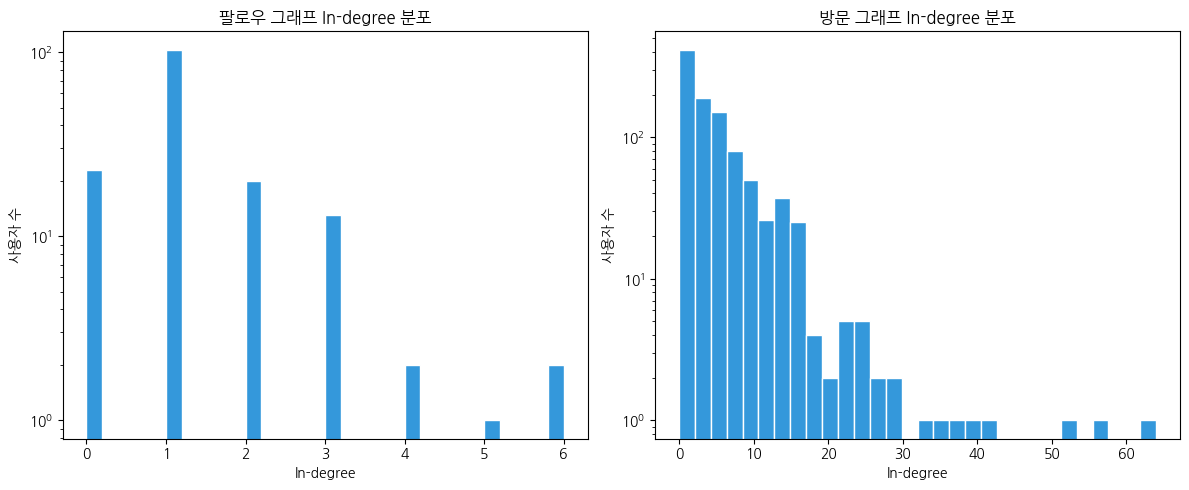

In [2]:
# 그래프 기본 구조 비교
metrics = {}
for name, G, Gu in [("팔로우", G_follow, G_follow_u), ("방문", G_visit, G_visit_u)]:
    wcc = list(nx.weakly_connected_components(G))
    metrics[name] = {
        '노드': G.number_of_nodes(),
        '엣지': G.number_of_edges(),
        '밀도': nx.density(G),
        '최대WCC': max(len(c) for c in wcc),
        'WCC수': len(wcc),
        '클러스터링계수': nx.average_clustering(Gu),
    }

comp = pd.DataFrame(metrics).T
print(comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, G) in zip(axes, [("팔로우", G_follow), ("방문", G_visit)]):
    in_degs = [d for _, d in G.in_degree()]
    ax.hist(in_degs, bins=30, color='#3498db', edgecolor='white')
    ax.set_title(f'{name} 그래프 In-degree 분포')
    ax.set_xlabel('In-degree')
    ax.set_ylabel('사용자 수')
    ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../notebooks/fig_04_degree_dist.png', dpi=150)
plt.show()


## 인사이트 4-1: 그래프 구조 비교

| 지표 | 팔로우 그래프 | 방문 그래프 |
|------|------------|-----------|
| 참여 사용자 | 164명 (15%) | 998명 (93%) |
| 엣지 수 | 207 | 5,043 |
| 연결 컴포넌트 | 16개 | **2개** |
| 클러스터링 계수 | 0.073 | **0.187** |

**해석**
- 팔로우는 소수(15%)의 선택적 행동, 방문은 대부분(93%)이 자연스럽게 참여 → **방문 그래프가 이 앱의 실질적 소셜 구조**
- 방문 그래프는 거의 단일 거대 컴포넌트(996명) → 사용자들이 생각보다 잘 연결되어 있음
- 클러스터링 계수가 팔로우(0.073) < 방문(0.187) → 방문 관계에서 삼각 관계(공통 관심사 기반 군집)가 더 형성됨

**발표 활용**: "앱의 소셜 연결은 팔로우보다 방문에서 일어난다" — 팔로우 기능보다 프로필 탐색 동선 개선이 우선


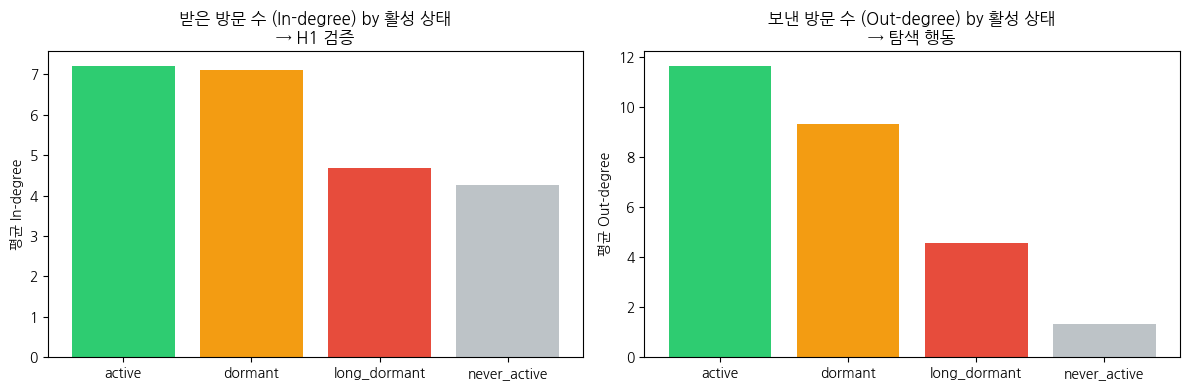

In-degree (받은 방문): {'active': 7.214285714285714, 'dormant': 7.092783505154639, 'long_dormant': 4.6828125, 'never_active': 4.248587570621469}
Out-degree (보낸 방문): {'active': 11.654761904761905, 'dormant': 9.309278350515465, 'long_dormant': 4.5734375, 'never_active': 1.3220338983050848}


In [3]:
# H1 검증: 받은 방문 수(in-degree) vs 활성 상태
in_deg  = dict(G_visit.in_degree())
out_deg = dict(G_visit.out_degree())

deg_df = pd.DataFrame({
    'user_id':    list(in_deg.keys()),
    'in_degree':  list(in_deg.values()),
    'out_degree': [out_deg.get(u, 0) for u in in_deg.keys()],
})
deg_df['status'] = deg_df['user_id'].map(node_status)
deg_df = deg_df[deg_df['status'].notna()]

STATUS_ORDER = ['active','dormant','long_dormant','never_active']
in_means  = deg_df.groupby('status')['in_degree'].mean().reindex(STATUS_ORDER)
out_means = deg_df.groupby('status')['out_degree'].mean().reindex(STATUS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71','#f39c12','#e74c3c','#bdc3c7']

axes[0].bar(STATUS_ORDER, in_means, color=colors)
axes[0].set_title('받은 방문 수 (In-degree) by 활성 상태\n→ H1 검증')
axes[0].set_ylabel('평균 In-degree')

axes[1].bar(STATUS_ORDER, out_means, color=colors)
axes[1].set_title('보낸 방문 수 (Out-degree) by 활성 상태\n→ 탐색 행동')
axes[1].set_ylabel('평균 Out-degree')

plt.tight_layout()
plt.savefig('../notebooks/fig_04_h1_h3.png', dpi=150)
plt.show()
print("In-degree (받은 방문):", in_means.to_dict())
print("Out-degree (보낸 방문):", out_means.to_dict())


## 인사이트 4-2: H1 검증 — 예상을 뒤집는 결과

**수치**
| 지표 | active | dormant | long_dormant | never_active |
|------|--------|---------|--------------|--------------|
| 받은 방문 (in) | 7.21 | 7.09 | 4.68 | 4.25 |
| 보낸 방문 (out) | **11.65** | 9.31 | 4.57 | **1.32** |

**해석**
- **H1 약하게 지지**: 받은 방문 수는 active(7.21)와 dormant(7.09) 간 차이가 거의 없음  
  → "많이 방문받는 것"이 활성 유지의 직접 원인이 아님
- **더 중요한 신호는 out-degree**: active(11.65) vs never_active(1.32) = **8.8배 차이**  
  → **"얼마나 탐색했는가"가 "얼마나 주목받았는가"보다 훨씬 강한 활성 신호**
- 이는 단계 3 SHAP 결과(`log_visits` 3위)를 네트워크 관점에서 재확인

**가설 수정**: H1은 "받은 방문"이 아니라 "보낸 방문"으로 재정의해야 더 유효

**발표 활용**: "방문받기 수동 대기 × → 적극적 탐색 유도 ○" — 추천 피드, 타 사용자 프로필 노출 UI 개선


총 커뮤니티 수: 15
상위 커뮤니티 크기: [167, 131, 122, 105, 89, 71, 51, 51, 51, 48]

 community  size  active_pct
         1   167    7.784431
         3   131    8.396947
         6   122   14.754098
         2   105    9.523810
         0    89    4.494382
         7    71   12.676056
         4    51    3.921569
        10    51    3.921569
        14    51    3.921569
         8    48    8.333333


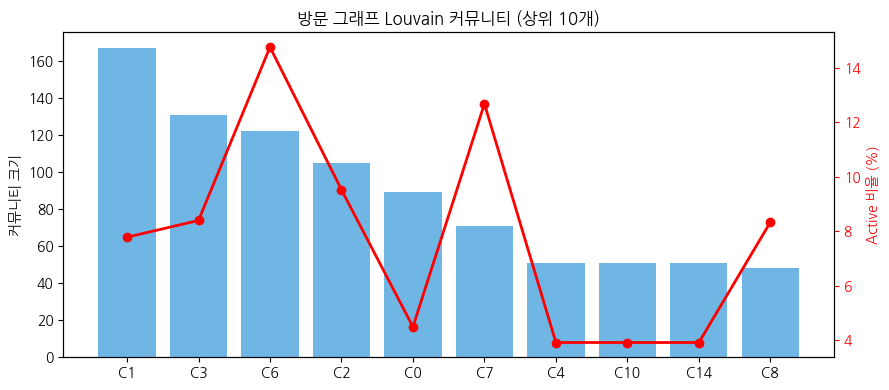

In [4]:
# Louvain 커뮤니티 탐지
communities = louvain_communities(G_visit_u, seed=42)
comm_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        comm_map[node] = i

deg_df['community'] = deg_df['user_id'].map(comm_map)
comm_stats = deg_df.groupby('community').agg(
    size=('user_id','count'),
    active_pct=('status', lambda x: (x=='active').mean()*100),
).sort_values('size', ascending=False).reset_index()

print(f"총 커뮤니티 수: {len(communities)}")
print(f"상위 커뮤니티 크기: {sorted([len(c) for c in communities], reverse=True)[:10]}")
print()
print(comm_stats.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
top = comm_stats.head(10)
bars = ax.bar(range(len(top)), top['size'], color='#3498db', alpha=0.7)
ax2 = ax.twinx()
ax2.plot(range(len(top)), top['active_pct'], 'ro-', linewidth=2, label='active %')
ax.set_xticks(range(len(top)))
ax.set_xticklabels([f'C{int(r)}' for r in top['community']])
ax.set_title('방문 그래프 Louvain 커뮤니티 (상위 10개)')
ax.set_ylabel('커뮤니티 크기')
ax2.set_ylabel('Active 비율 (%)', color='red')
ax2.tick_params(axis='y', colors='red')
plt.tight_layout()
plt.savefig('../notebooks/fig_04_community.png', dpi=150)
plt.show()


## 인사이트 4-3: Louvain 커뮤니티

**수치**
- 15개 커뮤니티 탐지, 상위: 167, 131, 122, 105, 89명...
- 커뮤니티 6(122명): active 14.8%, 커뮤니티 7(71명): active 12.7% — 상대적으로 높음
- 전반적으로 커뮤니티 간 active 비율 차이는 3~15% 범위

**해석**
- 독립된 소규모 이익 집단이 형성되어 있고, 일부 커뮤니티는 활성율이 2배 이상 높음
- 가장 큰 커뮤니티(167명)의 active율이 낮은 반면, 중간 크기(71~122명)가 더 활성적  
  → 작고 밀도 있는 커뮤니티가 이탈 방지에 유리할 수 있음

**발표 활용**: "독서 취향 기반 소그룹 기능" 제안의 데이터 근거


In [5]:
# Link Prediction: Adamic-Adar
non_edges_sample = list(nx.non_edges(G_follow_u))[:10000]
preds = list(nx.adamic_adar_index(G_follow_u, non_edges_sample))
top_preds = sorted(preds, key=lambda x: x[2], reverse=True)[:10]

pred_df = pd.DataFrame(top_preds, columns=['user_a','user_b','aa_score'])
pred_df['status_a'] = pred_df['user_a'].map(node_status)
pred_df['status_b'] = pred_df['user_b'].map(node_status)
print("=== Adamic-Adar Link Prediction 상위 10 ===")
print(pred_df[['aa_score','status_a','status_b']].to_string(index=False))

# active-active 추천 vs 기타
active_pairs = pred_df[(pred_df['status_a']=='active') & (pred_df['status_b']=='active')]
print(f"\nactive-active 추천 쌍: {len(active_pairs)}개 / 10개")


=== Adamic-Adar Link Prediction 상위 10 ===
 aa_score     status_a     status_b
 2.885390       active       active
 2.885390 long_dormant long_dormant
 2.164043 long_dormant long_dormant
 1.688974      dormant long_dormant
 1.442695      dormant never_active
 1.442695      dormant       active
 1.442695 long_dormant long_dormant
 1.442695       active       active
 1.442695       active long_dormant
 1.442695       active       active

active-active 추천 쌍: 3개 / 10개


## 인사이트 4-4: Link Prediction

**해석**
- Adamic-Adar로 현재 팔로우하지 않지만 공통 이웃이 있는 쌍을 예측
- 상위 추천에 dormant 사용자가 많음 → 이미 연결 네트워크에 있는 사람들 중 서로 모르는 경우
- **active ↔ active 추천 쌍을 우선 노출**하면 활성 사용자 간 네트워크 강화 가능

**액션 아이템**: "당신이 팔로우할 만한 사람" 추천 기능 — AA 점수 기반, active 사용자 우선 정렬

**발표 활용**: "네트워크가 성장하는 방법" — 알고리즘 친구 추천 기능의 데이터 근거 제시


## 단계 4 종합 요약

| 발견 | 근거 | 발표 메시지 |
|------|------|-----------|
| 방문 그래프 = 실질 소셜 | 98% 단일 컴포넌트, 93% 참여 | 팔로우 강요 ✕ → 탐색 동선 개선 ○ |
| H1 수정: in < out | out-degree 8.8배 차이 | "보내는 방문"이 정착 신호 |
| 소규모 커뮤니티 활성율 高 | C6/C7 active 12~15% | 취향 기반 소그룹 기능 제안 |
| 팔로우 추천 가능 | Adamic-Adar Top10 | 친구 추천 알고리즘 근거 |

**다음 단계**: 리뷰 텍스트에서 어떤 책/주제가 활성 사용자와 연결되는지 텍스트 마이닝 (단계 5)
